In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df=pd.read_csv('C:/Users/Sri Raga Narshitha/Downloads/clustering_data.csv', low_memory=False)
#1.Data filtering
state_df=df[df['StateName'].str.upper()=='ANDHRA PRADESH'].copy()
state_df['Latitude'] = pd.to_numeric(state_df['Latitude'], errors='coerce')
state_df['Longitude'] = pd.to_numeric(state_df['Longitude'], errors='coerce')
state_df.dropna(subset=['Latitude', 'Longitude'], inplace=True)
X = state_df[['Longitude', 'Latitude']].values

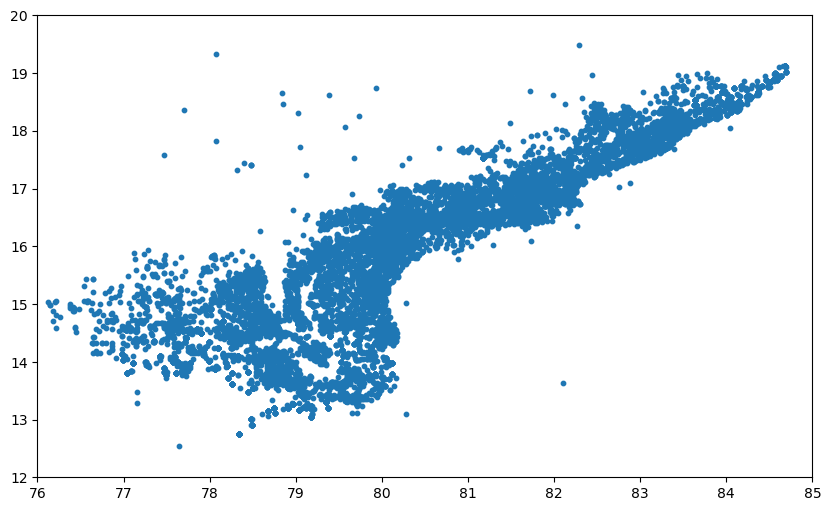

In [43]:
#Data Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(state_df['Longitude'], state_df['Latitude'], s=10)
plt.xlim(76, 85)
plt.ylim(12, 20)
plt.show()

In [37]:
#Clustering Analysis
class KMeansScratch:
    def __init__(self,k=7,max_iters=100,tol=1e-4):
        self.k=k
        self.max_iters=max_iters
        self.tol=tol
        self.centroids=None
    def fit(self,X):
        #taking random centroids
        idx =np.random.choice(len(X),self.k,replace=False)
        self.centroids=X[idx]
        for i in range(self.max_iters):
            #calculating the distances between the points and the centroids
            distances=np.linalg.norm(X[:,np.newaxis]-self.centroids,axis=2)
            #checking which centroid is closer to each point and grouping
            labels=np.argmin(distances,axis=1)
            #we are replacing each old centroid with the centroid of the cluster just formed
            new_centroids = np.array([X[labels == j].mean(axis=0) if len(X[labels == j]) > 0 
                                      else self.centroids[j] for j in range(self.k)])
            if np.all(np.abs(new_centroids-self.centroids)<self.tol):
                break
            self.centroids=new_centroids
        return labels
        

In [38]:

model=KMeansScratch(k=7)
state_df['Cluster']=model.fit(X)


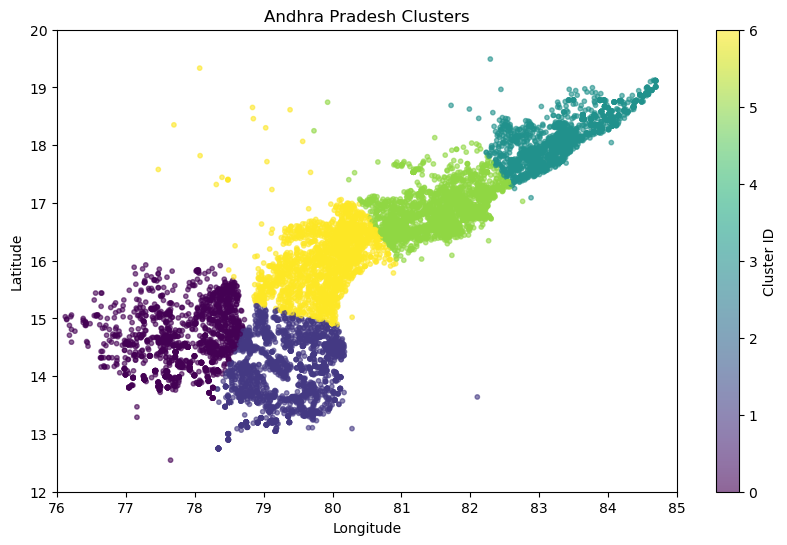

In [44]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(state_df['Longitude'], state_df['Latitude'], 
                     c=state_df['Cluster'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Andhra Pradesh Clusters')
plt.xlim(76, 85)
plt.ylim(12, 20)

plt.show()